## Supervised Machine Learning

- It is the type of ML where machine learns from labeled data.
- eg House price prediction(area, bedroom, location, ** price **)
- Target variable(output)/ dependent variable

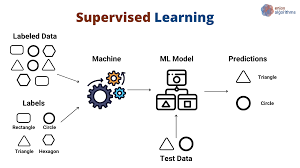

## types of supervised learning

### regression: 
- If our target variable is numerical then we use regression.
- For We are predicting the price of a car: Prediction : $2000
- Model: LinearRegression, DecisionTreeRegression, RandomForestRegressor

### classification:
- If our target variable is boolean then we use classification.
- for Example:- In brain tumor detection project the output is in yes/no
- Model: LogisticRegressor, DecisionTreeClassifier, MultinomialClassification, RandomForestClassifier

### Model/algorithm: 
- Linear Regression
- 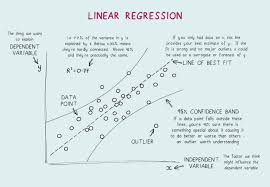
- Decision Tree 
- Logistic Regression (Sigmod equation)
- 
- RandomForest (entropy and information gain)
- SVM (Support Vector Machine)
- KNN (K Nearest Neighbour)
- Naive Bays classifier
- Gradient Boosting

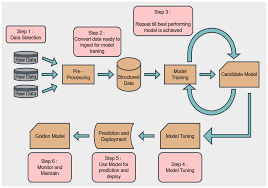

### house price prediction model


### Import laibraries

In [2]:
import pandas as pd # data frame
import numpy as np
import matplotlib.pyplot as plt # visualize
from sklearn.linear_model import LinearRegression, LogisticRegression # y=mx+c
from sklearn.model_selection import train_test_split # X_train, X_test, y_train, y_test
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv("house_price_dataset.csv")

df.head(10) 


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
5,2014-05-02 00:00:00,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,522 NE 88th St,Seattle,WA 98115,USA
6,2014-05-02 00:00:00,335000.0,2.0,2.00,1350,2560,1.0,0,0,3,1350,0,1976,0,2616 174th Ave NE,Redmond,WA 98052,USA
7,2014-05-02 00:00:00,482000.0,4.0,2.50,2710,35868,2.0,0,0,3,2710,0,1989,0,23762 SE 253rd Pl,Maple Valley,WA 98038,USA
8,2014-05-02 00:00:00,452500.0,3.0,2.50,2430,88426,1.0,0,0,4,1570,860,1985,0,46611-46625 SE 129th St,North Bend,WA 98045,USA
9,2014-05-02 00:00:00,640000.0,4.0,2.00,1520,6200,1.5,0,0,3,1520,0,1945,2010,6811 55th Ave NE,Seattle,WA 98115,USA


In [4]:
df.shape

(4600, 18)

### Step 3 Data cleaning and  Feature Engineering

In [5]:
## drop the high-cardanility columns
## Columns like street, statezip, country are almost unique

df = df.drop(['street', 'statezip', 'country'], axis = 1)
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond


In [6]:
df = df[df['price']>0]

In [7]:
## lets encode city
# there are 2 option: label encoding and one hot encoding


# le = LabelEncoder()

# df['city'] = le.fit_transform(df['city'])
# df.tail()

# one hot encoding
 
from sklearn.preprocessing import OneHotEncoder 

df = pd.get_dummies(df, columns = ['city'], drop_first = True)
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,city_SeaTac,city_Seattle,city_Shoreline,city_Skykomish,city_Snoqualmie,city_Snoqualmie Pass,city_Tukwila,city_Vashon,city_Woodinville,city_Yarrow Point
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,...,False,False,True,False,False,False,False,False,False,False
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,...,False,True,False,False,False,False,False,False,False,False
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,...,False,False,False,False,False,False,False,False,False,False
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,...,False,False,False,False,False,False,False,False,False,False
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,...,False,False,False,False,False,False,False,False,False,False


In [8]:
## feature engineering 

# df.info()
# df['house_age'] = df['yr_built'] - df['']

df['date'] = pd.to_datetime(df['date'], errors = 'coerce')

df['years_sold'] = df['date'].dt.year
df['month_sold'] = df['date'].dt.month

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,city_Shoreline,city_Skykomish,city_Snoqualmie,city_Snoqualmie Pass,city_Tukwila,city_Vashon,city_Woodinville,city_Yarrow Point,years_sold,month_sold
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,...,True,False,False,False,False,False,False,False,2014,5
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,...,False,False,False,False,False,False,False,False,2014,5
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,...,False,False,False,False,False,False,False,False,2014,5
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,...,False,False,False,False,False,False,False,False,2014,5
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,...,False,False,False,False,False,False,False,False,2014,5


In [9]:
df = df.drop(['date'],axis=1)

In [10]:
df['house_age'] = df['years_sold'] - df['yr_built']

df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,city_Skykomish,city_Snoqualmie,city_Snoqualmie Pass,city_Tukwila,city_Vashon,city_Woodinville,city_Yarrow Point,years_sold,month_sold,house_age
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,...,False,False,False,False,False,False,False,2014,5,59
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,...,False,False,False,False,False,False,False,2014,5,93
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,...,False,False,False,False,False,False,False,2014,5,48
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,...,False,False,False,False,False,False,False,2014,5,51
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,...,False,False,False,False,False,False,False,2014,5,38


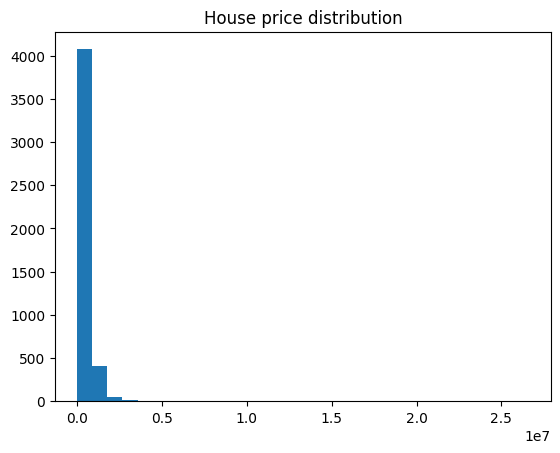

In [11]:
# EDA = Exploratory data analysis

plt.figure()
plt.hist(df['price'], bins=30)
plt.title("House price distribution")
plt.show()

In [12]:
# data is left screwed so we need to log transform

df['price'] = np.log1p(df['price'])

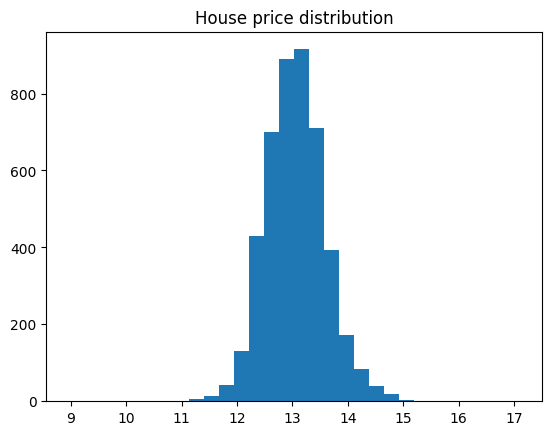

In [13]:
plt.figure()
plt.hist(df['price'], bins=30)
plt.title("House price distribution")
plt.show()

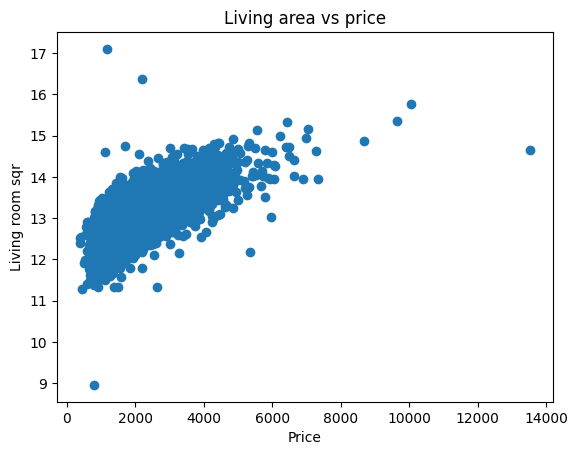

In [14]:
### pair plot

plt.figure()
plt.scatter(df['sqft_living'], df['price'])
plt.title("Living area vs price")
plt.xlabel("Price")
plt.ylabel("Living room sqr")
plt.show()

In [15]:
## correlation heatmap 

numeric_df = df.select_dtypes(include = ['int64','float64','int32'])

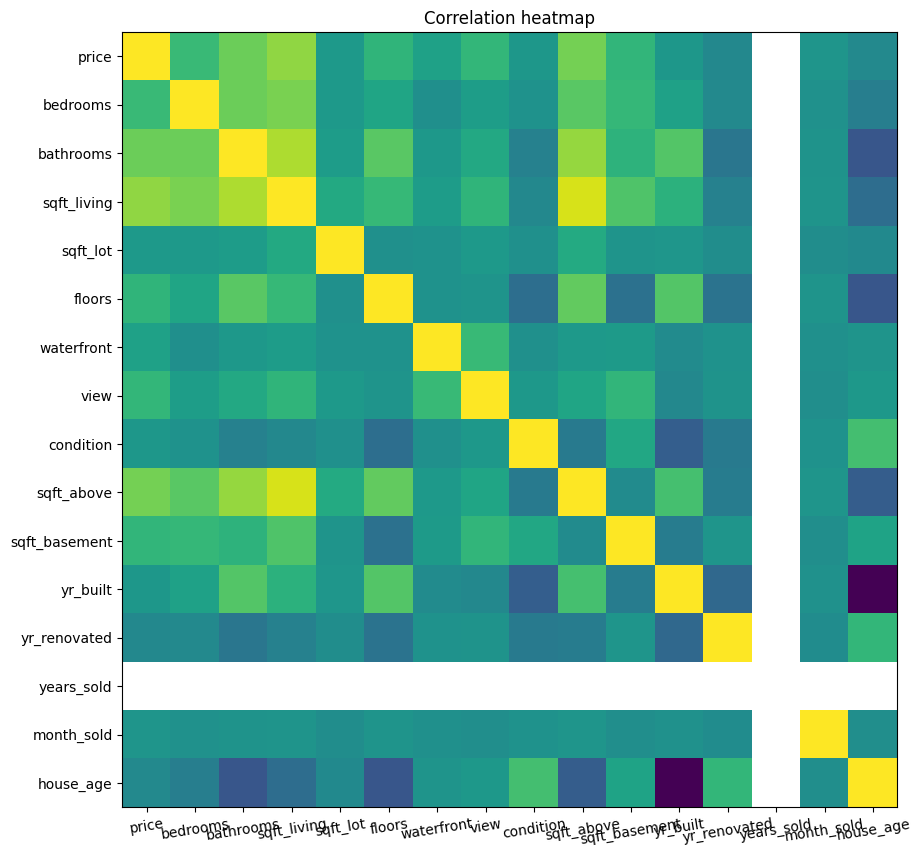

In [16]:
plt.figure(figsize=(10,12))

corr = numeric_df.corr()

plt.imshow(corr)

plt.xticks(range(len(corr.columns)), corr.columns, rotation = 9)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation heatmap")
plt.show()

### step 5 prepare data for modeling

In [30]:
### saperate features and target

X = df.drop('price',axis = 1)
y = df['price']

print(X.columns)
print(y.shape)

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'city_Auburn', 'city_Beaux Arts Village',
       'city_Bellevue', 'city_Black Diamond', 'city_Bothell', 'city_Burien',
       'city_Carnation', 'city_Clyde Hill', 'city_Covington',
       'city_Des Moines', 'city_Duvall', 'city_Enumclaw', 'city_Fall City',
       'city_Federal Way', 'city_Inglewood-Finn Hill', 'city_Issaquah',
       'city_Kenmore', 'city_Kent', 'city_Kirkland', 'city_Lake Forest Park',
       'city_Maple Valley', 'city_Medina', 'city_Mercer Island', 'city_Milton',
       'city_Newcastle', 'city_Normandy Park', 'city_North Bend',
       'city_Pacific', 'city_Preston', 'city_Ravensdale', 'city_Redmond',
       'city_Renton', 'city_Sammamish', 'city_SeaTac', 'city_Seattle',
       'city_Shoreline', 'city_Skykomish', 'city_Snoqualmie',
       'city_Snoqualmie Pass', 'city_Tukwila', 'city_Vashon',
 

### Step 6: train test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.2, random_state=42)


### step 7 model training

In [19]:
lr = LinearRegression()
model = lr.fit(X_train,y_train)

y_pred = model.predict(X_test)

In [20]:
print("Linear Regression Result")
print("R2:", r2_score(y_test,y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


Linear Regression Result
R2: 0.6779784427611664
MSE: 0.09478901409932143


In [23]:
# dumping the model

import joblib

joblib.dump(model,"house_price_prediction.pkl")


['house_price_prediction.pkl']

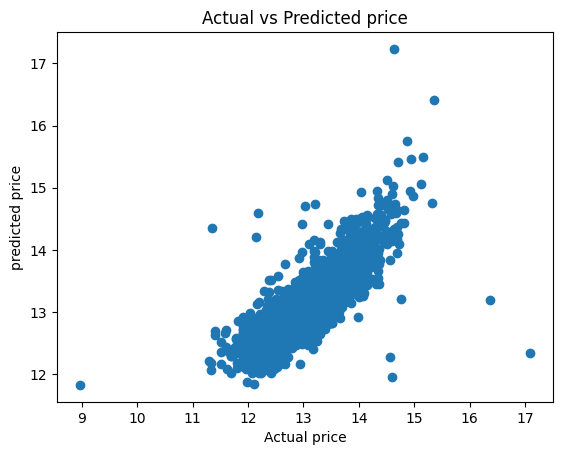

In [24]:
# actual value vs predicted value

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual price")
plt.ylabel("predicted price")
plt.title("Actual vs Predicted price")
plt.show()

In [ ]:
# testing 

lr_test = joblib.load("house_price_prediction.pkl")

sample_dataset = pd.DataFrame([{
    'bedrooms': 4,
    'bathrooms': 2,
    'sqft_living': 2000,
    'sqft_lot': 8000,
    'floors': 2.0,
    'waterfront': 0,
    'view': 0,
    'condition': 3,
    'sqft_above': 1500,
    'sqft_basement': 500,
    'yr_built': 2005,
    'yr_renovated': 0,
    'city_Auburn': 0,
    'city_Beaux Arts Village': 0,
    'city_Bellevue': 0,
    'city_Black Diamond': 0,
    'city_Bothell': 0,
    'city_Burien': 0,
    'city_Carnation': 0,
    'city_Clyde Hill': 0,
    'city_Covington': 0,
    'city_Des Moines': 0,
    'city_Duvall': 0,
    'city_Enumclaw': 0,
    'city_Fall City': 0,
    'city_Federal Way': 0,
    'city_Inglewood-Finn Hill': 0,
    'city_Issaquah': 0,
    'city_Kenmore': 0,
    'city_Kent': 0,
    'city_Kirkland': 0,
    'city_Lake Forest Park': 0,
    'city_Maple Valley': 0,
    'city_Medina': 0,
    'city_Mercer Island': 0,
    'city_Milton': 0,
    'city_Newcastle': 0,
    'city_Normandy Park': 0,
    'city_North Bend': 0,
    'city_Pacific': 0,
    'city_Preston': 0,
    'city_Ravensdale': 0,
    'city_Redmond': 0,
    'city_Renton': 0,
    'city_Sammamish': 0,
    'city_SeaTac': 0,
    'city_Seattle': 1,
    'city_Shoreline': 0,
    'city_Skykomish': 0,
    'city_Snoqualmie': 0,
    'city_Snoqualmie Pass': 0,
    'city_Tukwila': 0,
    'city_Vashon': 0,
    'city_Woodinville': 0,
    'city_Yarrow Point': 0,
    'years_sold': 2015,
    'month_sold': 6,
    'house_age': 10
}])

prediction = lr_test.predict(sample_dataset)

print("Predicted Price:", prediction[0])

Predicted Price: 13.014408929478657
